In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import re

In [25]:

files = glob.glob(r"DataSets\PAMAP2\Subjects\subject*.dat")

dfs = []

for file in files:
    
    # Extraer ID del sujeto
    subject_id = int(re.search(r"subject(\d+)", file).group(1))
    
    df = pd.read_csv(file, sep=r"\s+", header=None)
    
    df["subject_id"] = subject_id
    
    dfs.append(df)

PAMAP2DATASET = pd.concat(dfs, ignore_index=True)

columns = [
    "timestamp",
    "activity_id",
    "heart_rate"
]

imu_labels = [
    "temp",
    "acc16_x", "acc16_y", "acc16_z",
    "acc6_x", "acc6_y", "acc6_z",
    "gyro_x", "gyro_y", "gyro_z",
    "mag_x", "mag_y", "mag_z",
    "orient_1", "orient_2", "orient_3", "orient_4"
]

for sensor in ["hand", "chest", "ankle"]:
    for label in imu_labels:
        columns.append(f"{sensor}_{label}")

columns.append("subject_id")

PAMAP2DATASET.columns = columns

pd.set_option('display.max_columns', None)

1. Para cada base de datos presenta sus dimensiones y las primeras 5 líneas.

In [26]:
PAMAP2DATASET.shape

(2872533, 55)

In [27]:
PAMAP2DATASET.head()

,timestamp,activity_id,heart_rate,hand_temp,hand_acc16_x,hand_acc16_y,hand_acc16_z,hand_acc6_x,hand_acc6_y,hand_acc6_z,hand_gyro_x,hand_gyro_y,hand_gyro_z,hand_mag_x,hand_mag_y,hand_mag_z,hand_orient_1,hand_orient_2,hand_orient_3,hand_orient_4,chest_temp,chest_acc16_x,chest_acc16_y,chest_acc16_z,chest_acc6_x,chest_acc6_y,chest_acc6_z,chest_gyro_x,chest_gyro_y,chest_gyro_z,chest_mag_x,chest_mag_y,chest_mag_z,chest_orient_1,chest_orient_2,chest_orient_3,chest_orient_4,ankle_temp,ankle_acc16_x,ankle_acc16_y,ankle_acc16_z,ankle_acc6_x,ankle_acc6_y,ankle_acc6_z,ankle_gyro_x,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,ankle_orient_1,ankle_orient_2,ankle_orient_3,ankle_orient_4,subject_id
0,8.38,0,104.0,30.0,2.37223,8.60074,3.51048,2.43954,8.76165,3.35465,-0.092217,0.056812,-0.015845,14.6806,-69.2128,-5.58905,1.0,0.0,0.0,0.0,31.8125,0.238080,9.80003,-1.68896,0.265304,9.81549,-1.41344,-0.005065,-0.006781,-0.005663,0.471960,-51.0499,43.2903,1.0,0.0,0.0,0.0,30.3125,9.65918,-1.65569,-0.099797,9.64689,-1.55576,0.310404,0.008300,0.009250,-0.017580,-61.1888,-38.9599,-58.1438,1.0,0.0,0.0,0.0,101
1,8.39,0,NaN,30.0,2.18837,8.56560,3.66179,2.39494,8.55081,3.64207,-0.024413,0.047759,0.006474,14.8991,-69.2224,-5.82311,1.0,0.0,0.0,0.0,31.8125,0.319530,9.61282,-1.49328,0.234939,9.78539,-1.42846,0.013685,0.001486,-0.041522,1.016900,-50.3966,43.1768,1.0,0.0,0.0,0.0,30.3125,9.69370,-1.57902,-0.215687,9.61670,-1.61630,0.280488,-0.006577,-0.004638,0.000368,-59.8479,-38.8919,-58.5253,1.0,0.0,0.0,0.0,101
2,8.40,0,NaN,30.0,2.37357,8.60107,3.54898,2.30514,8.53644,3.73280,-0.057976,0.032574,-0.006988,14.2420,-69.5197,-5.12442,1.0,0.0,0.0,0.0,31.8125,0.235593,9.72421,-1.76621,0.173850,9.72528,-1.51894,-0.039923,0.034056,-0.002113,0.383136,-51.8336,43.7782,1.0,0.0,0.0,0.0,30.3125,9.58944,-1.73276,0.092914,9.63173,-1.58605,0.280311,0.003014,0.000148,0.022495,-60.7361,-39.4138,-58.3999,1.0,0.0,0.0,0.0,101
3,8.41,0,NaN,30.0,2.07473,8.52853,3.66021,2.33528,8.53622,3.73277,-0.002352,0.032810,-0.003747,14.8908,-69.5439,-6.17367,1.0,0.0,0.0,0.0,31.8125,0.388697,9.53572,-1.72410,0.157969,9.64994,-1.57952,0.007513,-0.010498,-0.020684,0.315400,-49.8144,43.1670,1.0,0.0,0.0,0.0,30.3125,9.58814,-1.77040,0.054545,9.63197,-1.63135,0.340997,0.003175,-0.020301,0.011275,-60.4091,-38.7635,-58.3956,1.0,0.0,0.0,0.0,101
4,8.42,0,NaN,30.0,2.22936,8.83122,3.70000,2.23055,8.59741,3.76295,0.012269,0.018305,-0.053325,15.5612,-68.8196,-6.28927,1.0,0.0,0.0,0.0,31.8125,0.315800,9.49908,-1.60914,0.233506,9.57411,-1.44418,-0.003822,-0.011217,-0.025975,-0.297733,-51.8097,43.6453,1.0,0.0,0.0,0.0,30.3125,9.69771,-1.65625,-0.060809,9.64699,-1.64647,0.340965,0.012698,-0.014303,-0.002823,-61.5199,-39.3879,-58.2694,1.0,0.0,0.0,0.0,101


2. Identifica y elimina los datos ausentes.

In [28]:
PAMAP2DATASET.isnull().sum()

timestamp               0
activity_id             0
heart_rate        2610265
hand_temp           13141
hand_acc16_x        13141
hand_acc16_y        13141
hand_acc16_z        13141
hand_acc6_x         13141
hand_acc6_y         13141
hand_acc6_z         13141
hand_gyro_x         13141
hand_gyro_y         13141
hand_gyro_z         13141
hand_mag_x          13141
hand_mag_y          13141
hand_mag_z          13141
hand_orient_1       13141
hand_orient_2       13141
hand_orient_3       13141
hand_orient_4       13141
chest_temp           3563
chest_acc16_x        3563
chest_acc16_y        3563
chest_acc16_z        3563
chest_acc6_x         3563
chest_acc6_y         3563
chest_acc6_z         3563
chest_gyro_x         3563
chest_gyro_y         3563
chest_gyro_z         3563
chest_mag_x          3563
chest_mag_y          3563
chest_mag_z          3563
chest_orient_1       3563
chest_orient_2       3563
chest_orient_3       3563
chest_orient_4       3563
ankle_temp          11749
ankle_acc16_

In [44]:
PAMAP2DATASET_interpolated = PAMAP2DATASET.copy()

PAMAP2DATASET_interpolated = (
    PAMAP2DATASET_interpolated
    .sort_values(["subject_id", "timestamp"])
)

numeric_cols = PAMAP2DATASET_interpolated.select_dtypes(include="number").columns
numeric_cols = numeric_cols.drop(["activity_id", "subject_id"])

PAMAP2DATASET_interpolated[numeric_cols] = (
    PAMAP2DATASET_interpolated
    .groupby("subject_id")[numeric_cols]
    .transform(lambda x: x.interpolate(method="linear"))
)

PAMAP2DATASET_interpolated = (
    PAMAP2DATASET_interpolated
    .bfill()
    .ffill()
)

3. Presenta los tipos de datos de cada atributo de cada base de datos.

In [45]:
PAMAP2DATASET.dtypes

timestamp         float64
activity_id         int64
heart_rate        float64
hand_temp         float64
hand_acc16_x      float64
hand_acc16_y      float64
hand_acc16_z      float64
hand_acc6_x       float64
hand_acc6_y       float64
hand_acc6_z       float64
hand_gyro_x       float64
hand_gyro_y       float64
hand_gyro_z       float64
hand_mag_x        float64
hand_mag_y        float64
hand_mag_z        float64
hand_orient_1     float64
hand_orient_2     float64
hand_orient_3     float64
hand_orient_4     float64
chest_temp        float64
chest_acc16_x     float64
chest_acc16_y     float64
chest_acc16_z     float64
chest_acc6_x      float64
chest_acc6_y      float64
chest_acc6_z      float64
chest_gyro_x      float64
chest_gyro_y      float64
chest_gyro_z      float64
chest_mag_x       float64
chest_mag_y       float64
chest_mag_z       float64
chest_orient_1    float64
chest_orient_2    float64
chest_orient_3    float64
chest_orient_4    float64
ankle_temp        float64
ankle_acc16_

4. Presenta el resumen estadístico de cada uno de los atributos de cada base de datos.

In [46]:
PAMAP2DATASET.describe()

,timestamp,activity_id,heart_rate,hand_temp,hand_acc16_x,hand_acc16_y,hand_acc16_z,hand_acc6_x,hand_acc6_y,hand_acc6_z,hand_gyro_x,hand_gyro_y,hand_gyro_z,hand_mag_x,hand_mag_y,hand_mag_z,hand_orient_1,hand_orient_2,hand_orient_3,hand_orient_4,chest_temp,chest_acc16_x,chest_acc16_y,chest_acc16_z,chest_acc6_x,chest_acc6_y,chest_acc6_z,chest_gyro_x,chest_gyro_y,chest_gyro_z,chest_mag_x,chest_mag_y,chest_mag_z,chest_orient_1,chest_orient_2,chest_orient_3,chest_orient_4,ankle_temp,ankle_acc16_x,ankle_acc16_y,ankle_acc16_z,ankle_acc6_x,ankle_acc6_y,ankle_acc6_z,ankle_gyro_x,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,ankle_orient_1,ankle_orient_2,ankle_orient_3,ankle_orient_4,subject_id
count,2.872533e+06,2.872533e+06,262268.000000,2.859392e+06,2.859392e+06,2.859392e+06,2.859392e+06,2.859392e+06,2.859392e+06,2.859392e+06,2.859392e+06,2.859392e+06,2.859392e+06,2.859392e+06,2.859392e+06,2.859392e+06,2.859392e+06,2.859392e+06,2.859392e+06,2.859392e+06,2.868970e+06,2.868970e+06,2.868970e+06,2.868970e+06,2.868970e+06,2.868970e+06,2.868970e+06,2.868970e+06,2.868970e+06,2.868970e+06,2.868970e+06,2.868970e+06,2.868970e+06,2.868970e+06,2.868970e+06,2.868970e+06,2.868970e+06,2.860784e+06,2.860784e+06,2.860784e+06,2.860784e+06,2.860784e+06,2.860784e+06,2.860784e+06,2.860784e+06,2.860784e+06,2.860784e+06,2.860784e+06,2.860784e+06,2.860784e+06,2.860784e+06,2.860784e+06,2.860784e+06,2.860784e+06,2.872533e+06
mean,1.834354e+03,5.466243e+00,109.872508,3.265258e+01,-4.960786e+00,3.587758e+00,3.168417e+00,-4.889420e+00,3.584267e+00,3.349479e+00,-3.704744e-03,3.213540e-02,-6.167531e-03,2.116857e+01,-1.438908e+01,-2.164451e+01,5.665828e-01,-5.637362e-02,-1.387280e-01,-3.253652e-02,3.614974e+01,3.763755e-01,8.512205e+00,-1.518129e+00,2.448624e-01,8.505998e+00,-1.183563e+00,5.538698e-03,8.371162e-03,-2.106222e-02,3.579709e+00,-3.185773e+01,5.516828e+00,5.323223e-01,-4.070343e-01,5.515427e-02,4.855860e-02,3.368513e+01,9.545448e+00,-1.232476e-01,-2.461503e+00,9.521348e+00,-2.062646e-02,-2.039830e+00,8.635143e-03,-3.450122e-02,7.752030e-03,-3.272102e+01,1.593304e+00,1.689044e+01,3.986417e-01,2.154835e-02,3.091533e-01,-1.878725e-02,1.045005e+02
std,1.105689e+03,6.331333e+00,25.870036,1.844274e+00,5.985029e+00,6.277838e+00,3.843923e+00,5.992726e+00,6.055750e+00,3.840650e+00,1.297393e+00,8.870178e-01,1.452335e+00,2.402141e+01,2.409442e+01,2.061562e+01,3.053876e-01,3.780510e-01,3.355073e-01,5.538527e-01,1.585569e+00,1.620532e+00,4.234937e+00,4.173970e+00,1.619479e+00,4.206740e+00,4.188157e+00,4.020286e-01,5.389323e-01,2.924429e-01,1.645178e+01,1.611910e+01,1.992197e+01,2.894888e-01,2.945579e-01,4.763355e-01,3.848282e-01,1.184363e+00,5.711595e+00,6.839350e+00,3.556998e+00,5.346379e+00,6.382194e+00,3.191150e+00,1.073556e+00,5.966026e-01,1.842552e+00,1.887860e+01,2.161181e+01,2.030858e+01,3.034561e-01,5.691302e-01,3.237875e-01,4.731373e-01,2.367003e+00
min,5.640000e+00,0.000000e+00,57.000000,2.475000e+01,-1.453670e+02,-1.043010e+02,-1.014520e+02,-6.148950e+01,-6.186800e+01,-6.193470e+01,-2.813540e+01,-2.221270e+01,-1.669970e+01,-1.039410e+02,-2.000430e+02,-4.976320e+02,-4.522460e-01,-9.999960e-01,-9.982610e-01,-9.993260e-01,3.093750e+01,-3.920340e+01,-4.692460e+01,-8.016680e+01,-3.420400e+01,-4.825720e+01,-6.180410e+01,-1.252510e+01,-8.499900e+00,-7.851890e+00,-7.624520e+01,-1.224800e+02,-6.668470e+01,-2.220890e-01,-9.994670e-01,-9.996350e-01,-8.801950e-01,2.912500e+01,-1.550680e+02,-1.576150e+02,-1.589260e+02,-6.130230e+01,-6.190640e+01,-6.232120e+01,-2.399500e+01,-1.812690e+01,-1.401960e+01,-1.728650e+02,-1.379080e+02,-1.092890e+02,-2.536280e-01,-9.568760e-01,-8.768380e-01,-9.972810e-01,1.010000e+02
25%,8.931600e+02,0.000000e+00,90.000000,3.143750e+01,-9.028420e+00,1.290268e+00,9.685818e-01,-8.933270e+00,1.284680e+00,1.164040e+00,-3.477165e-01,-1.970403e-01,-3.011370e-01,5.254000e+00,-2.962280e+01,-3.526602e+01,3.000760e-01,-3.550642e-01,-4.132433e-01,-5.603453e-01,3.512500e+01,-4.201365e-01,7.298863e+00,-3.878680e+00,-5.343240e-01,7.285490e+0

5. Presenta la distribución de clases de cada base de datos.

In [47]:
PAMAP2DATASET['activity_id'].value_counts()

activity_id
0     929661
4     238761
17    238690
1     192523
3     189931
7     188107
2     185188
16    175353
6     164600
12    117216
13    104944
5      98199
24     49360
Name: count, dtype: int64

6. Presenta la correlación entre atributos de cada base de datos.

In [48]:
sensores_fisicos = PAMAP2DATASET.drop(columns=['activity_id', 'timestamp'])
sensores_fisicos.corr()

,heart_rate,hand_temp,hand_acc16_x,hand_acc16_y,hand_acc16_z,hand_acc6_x,hand_acc6_y,hand_acc6_z,hand_gyro_x,hand_gyro_y,hand_gyro_z,hand_mag_x,hand_mag_y,hand_mag_z,hand_orient_1,hand_orient_2,hand_orient_3,hand_orient_4,chest_temp,chest_acc16_x,chest_acc16_y,chest_acc16_z,chest_acc6_x,chest_acc6_y,chest_acc6_z,chest_gyro_x,chest_gyro_y,chest_gyro_z,chest_mag_x,chest_mag_y,chest_mag_z,chest_orient_1,chest_orient_2,chest_orient_3,chest_orient_4,ankle_temp,ankle_acc16_x,ankle_acc16_y,ankle_acc16_z,ankle_acc6_x,ankle_acc6_y,ankle_acc6_z,ankle_gyro_x,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,ankle_orient_1,ankle_orient_2,ankle_orient_3,ankle_orient_4,subject_id
heart_rate,1.000000,-0.377434,-0.195231,0.027505,-0.212936,-0.202903,0.024732,-0.220252,0.007518,0.050337,-0.002146,0.201481,-0.085733,0.078327,0.081100,-0.001428,-0.076474,0.014375,-0.168573,-0.015829,0.143850,-0.334757,-0.018194,0.144917,-0.338139,0.006605,0.014977,-0.016205,-0.111285,-0.354951,0.351828,-0.011348,-0.032794,-0.183927,-0.187676,-0.085368,0.225549,0.156596,0.006673,0.238711,0.171398,0.004436,0.004378,-0.016251,0.005219,-0.265142,-0.169421,-0.069890,0.317111,0.019624,-0.018784,0.133263,-0.111450
hand_temp,-0.377434,1.000000,0.008814,-0.048756,0.071363,0.022824,-0.045302,0.088325,-0.017828,-0.016174,-0.000226,-0.061048,-0.017995,-0.023357,-0.078981,0.030988,-0.032036,-0.056026,0.783425,0.030564,0.028902,0.081490,0.045570,0.026814,0.091983,-0.001382,-0.008361,0.003433,-0.047294,-0.000054,-0.169583,-0.018656,0.067053,0.160229,0.130516,0.530370,-0.040244,-0.035769,-0.068751,-0.038156,-0.040039,-0.071150,0.001004,0.018464,0.002370,0.083927,0.097733,0.137942,-0.091626,0.052247,-0.011366,0.049884,0.143514
hand_acc16_x,-0.195231,0.008814,1.000000,-0.017663,0.209834,0.983423,-0.012316,0.212018,0.018378,-0.077437,0.027825,-0.582024,-0.010790,-0.157724,0.203864,-0.085870,0.434591,0.077585,-0.131091,-0.006081,-0.355769,0.354554,-0.007007,-0.360914,0.353820,-0.055830,-0.039676,0.062322,0.174080,0.237989,-0.260343,0.278307,0.177207,0.028300,0.050408,-0.095826,-0.246597,-0.084342,0.017493,-0.275475,-0.092452,0.017098,0.029868,-0.052798,0.081042,0.046091,0.164149,-0.042624,-0.011501,0.045190,-0.059901,-0.075362,-0.075830
hand_acc16_y,0.027505,-0.048756,-0.017663,1.000000,-0.086027,-0.005751,0.953431,-0.089441,0.149000,-0.004391,0.014803,-0.091984,-0.482826,0.102037,0.053591,-0.267495,-0.007094,0.055350,-0.049611,0.041408,0.196591,-0.130098,0.038993,0.208363,-0.136855,0.051220,0.005124,0.030234,-0.073452,-0.096963,0.052529,0.053440,0.076524,0.017283,0.018737,0.105405,0.047569,0.100511,0.028490,0.058050,0.112635,0.031516,-0.002731,-0.023453,-0.030489,-0.079622,-0.099271,0.034909,0.093702,-0.061927,-0.099474,-0.036549,-0.343700
hand_acc16_z,-0.212936,0.071363,0.209834,-0.086027,1.000000,0.208533,-0.087838,0.971862,-0.023092,-0.007972,-0.071962,-0.140716,0.133720,-0.533155,0.174069,0.077050,0.161868,0.043415,-0.017592,-0.093982,-0.064849,0.137393,-0.096639,-0.064552,0.137106,0.005258,-0.047579,0.031067,0.166735,0.176496,-0.124615,0.139552,0.037446,0.070866,0.097265,-0.022397,-0.148150,-0.048776,0.011705,-0.153594,-0.052041,0.013808,0.013337,-0.015222,0.024216,0.081521,0.068946,-0.041575,-0.040512,0.024160,-0.041686,-0.059069,0.027913
hand_acc6_x,-0.202903,0.022824,0.983423,-0.005751,0.208533,1.000000,-0.009103,0.209613,0.022020,-0.057555,0.023991,-0.585306,-0.011341,-0.158525,0.203683,-0.085733,0.435014,0.077116,-0.120730,-0.004754,-0.352970,0.356873,-0.007959,-0.360853,0.356049,-0.043422,-0.033475,0.057925,0.173558,0.239292,-0.263896,0.278603,0.178244,0.030566,0.052057,-0.088646,-0.241306,-0.083543,0.017203,-0.269808,-0.092281,0.017205,0.030883,-0.051301,0.072410,0.046946,0.168451,-0.039967,-0.013690,0.046776,-0.058163,-0.074843,-0.073999
hand_acc6_y,0.024732,-0.045302,-0.012316,0.953431,-0.087838,-0.009103,1.000000,-0.081092,0.098868,-0.011712,0.039500,-0.091957,-0.498848,0.106445,0.054509,-0.277476,-0.012482,0.057935,-0.047818,0.042713,0.191876,-0.135061,

7. Presenta el histograma de los atributos de cada base de datos.

<function matplotlib.pyplot.show(close=None, block=None)>

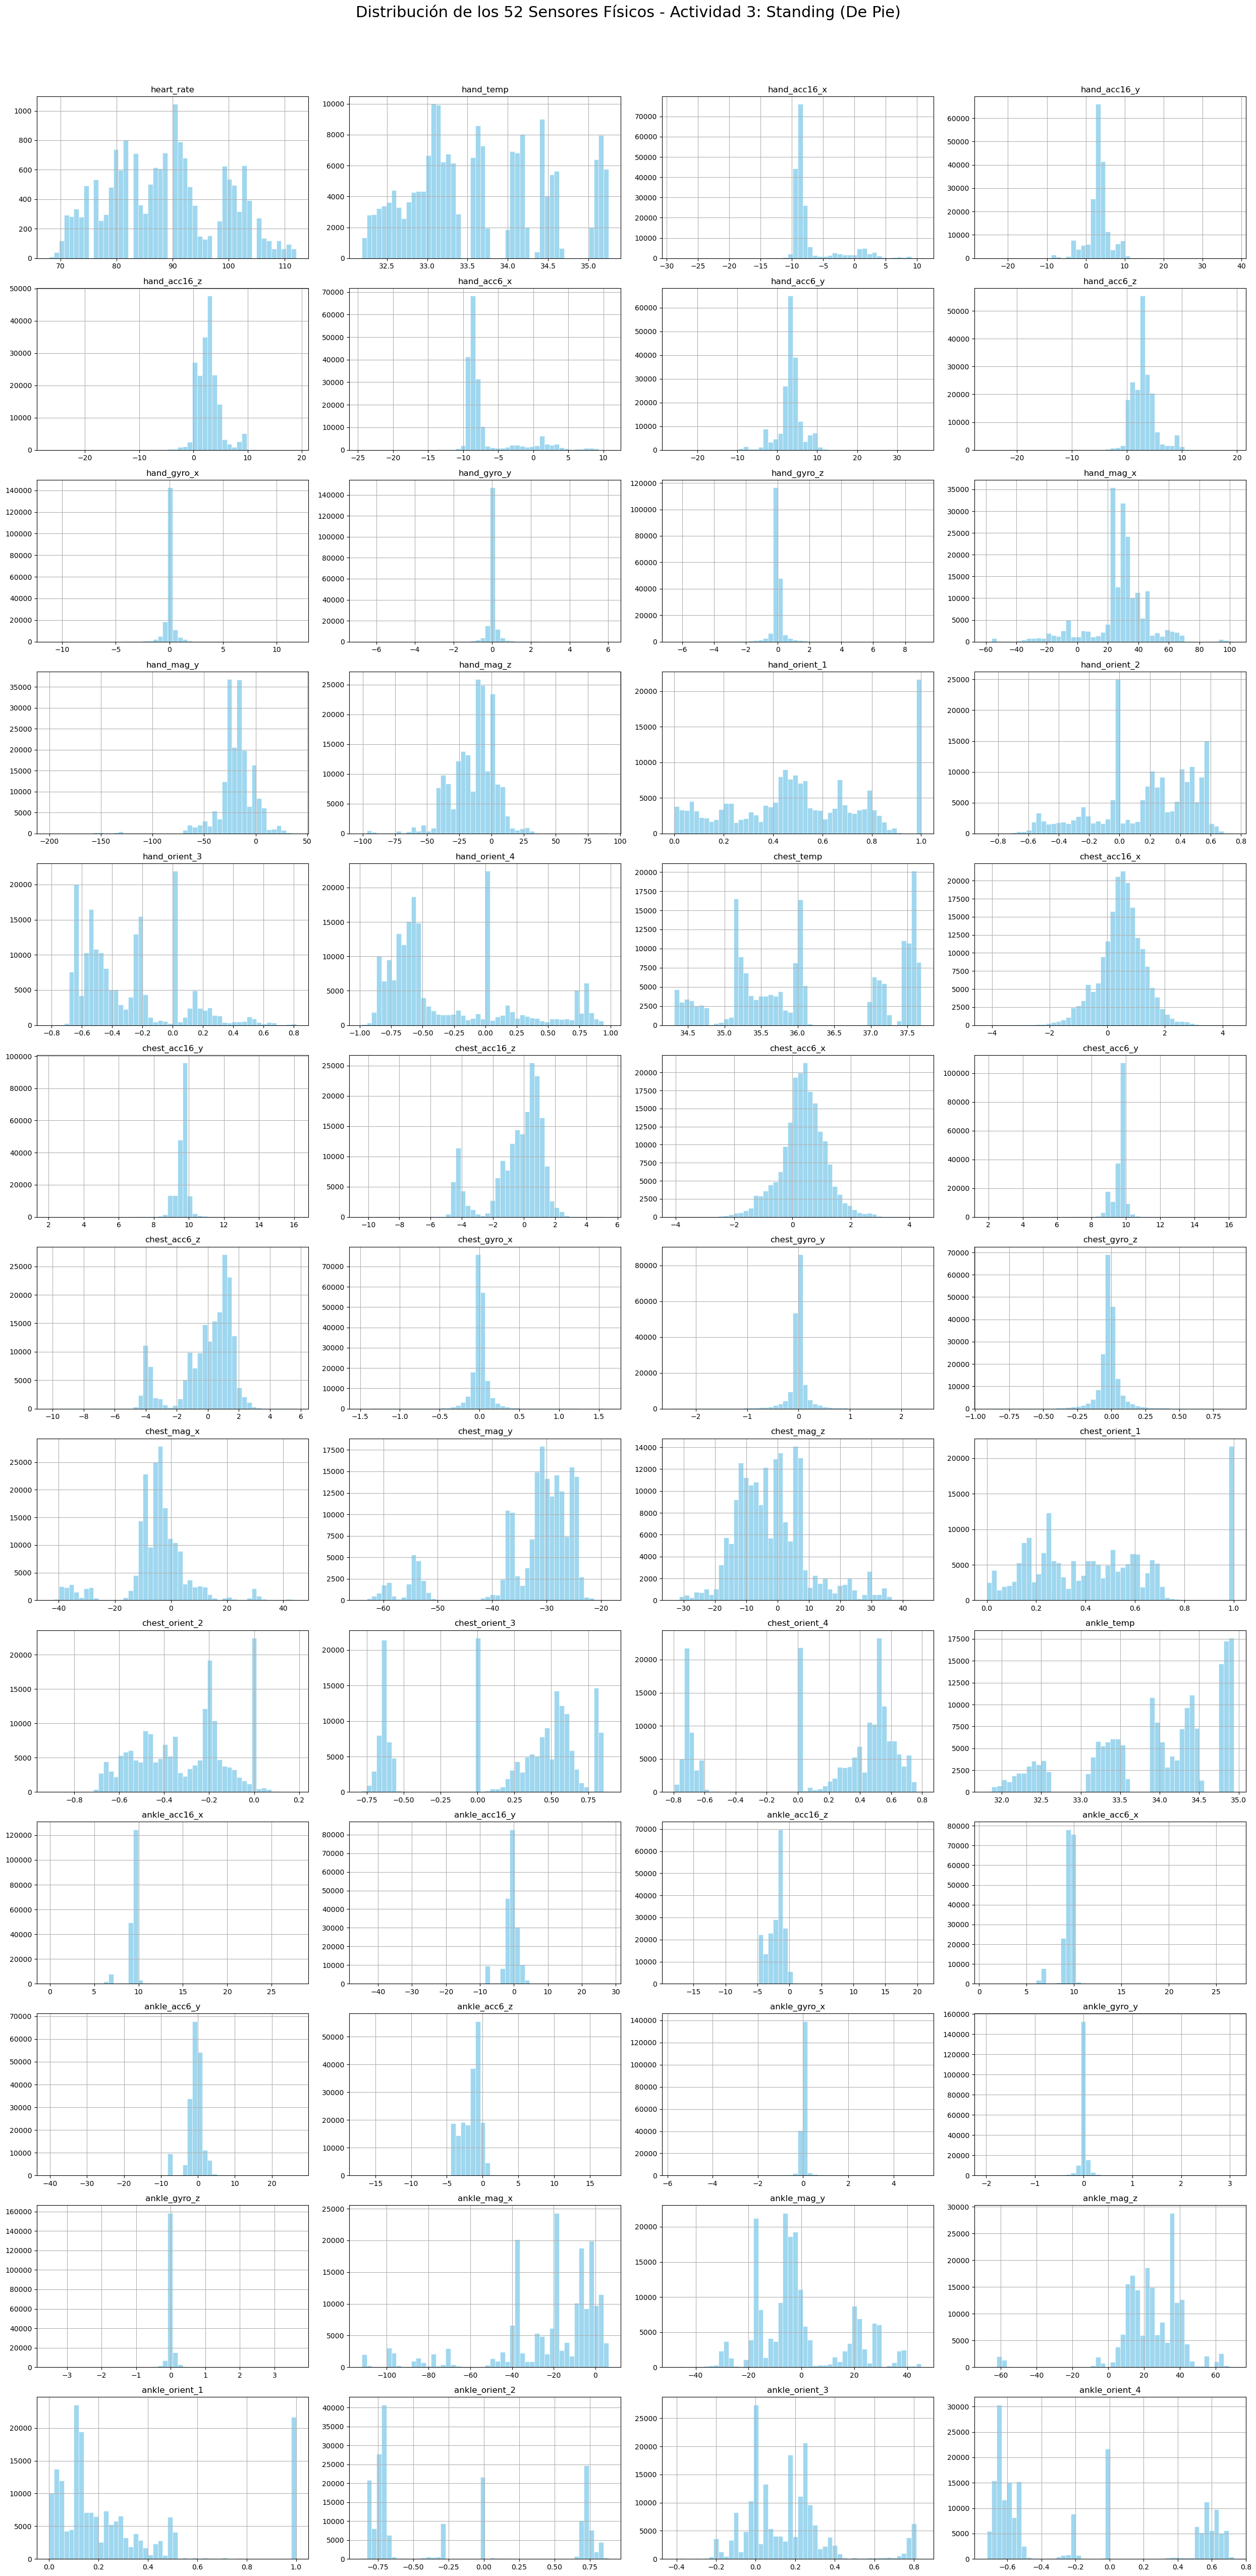

In [49]:
## Filtramos para mostrar actividad 2 (de pie)
actividad_standing = PAMAP2DATASET[PAMAP2DATASET['activity_id'] == 3]

# Le quitamos las etiquetas
sensores_standing = actividad_standing.drop(columns=['activity_id', 'timestamp', 'subject_id'])

sensores_standing.hist(
    bins=50, 
    layout=(13,4),
    figsize=(25, 50), 
    color='skyblue', 
    edgecolor='white', 
    linewidth=0.5,
    alpha=0.8
)

plt.suptitle('Distribución de los 52 Sensores Físicos - Actividad 3: Standing (De Pie)', fontsize=22, y=1.02)
plt.tight_layout()

plt.show

8. Genera la gráfica de densidad para la distribución de los atributos de cada base de datos.

<function matplotlib.pyplot.show(close=None, block=None)>

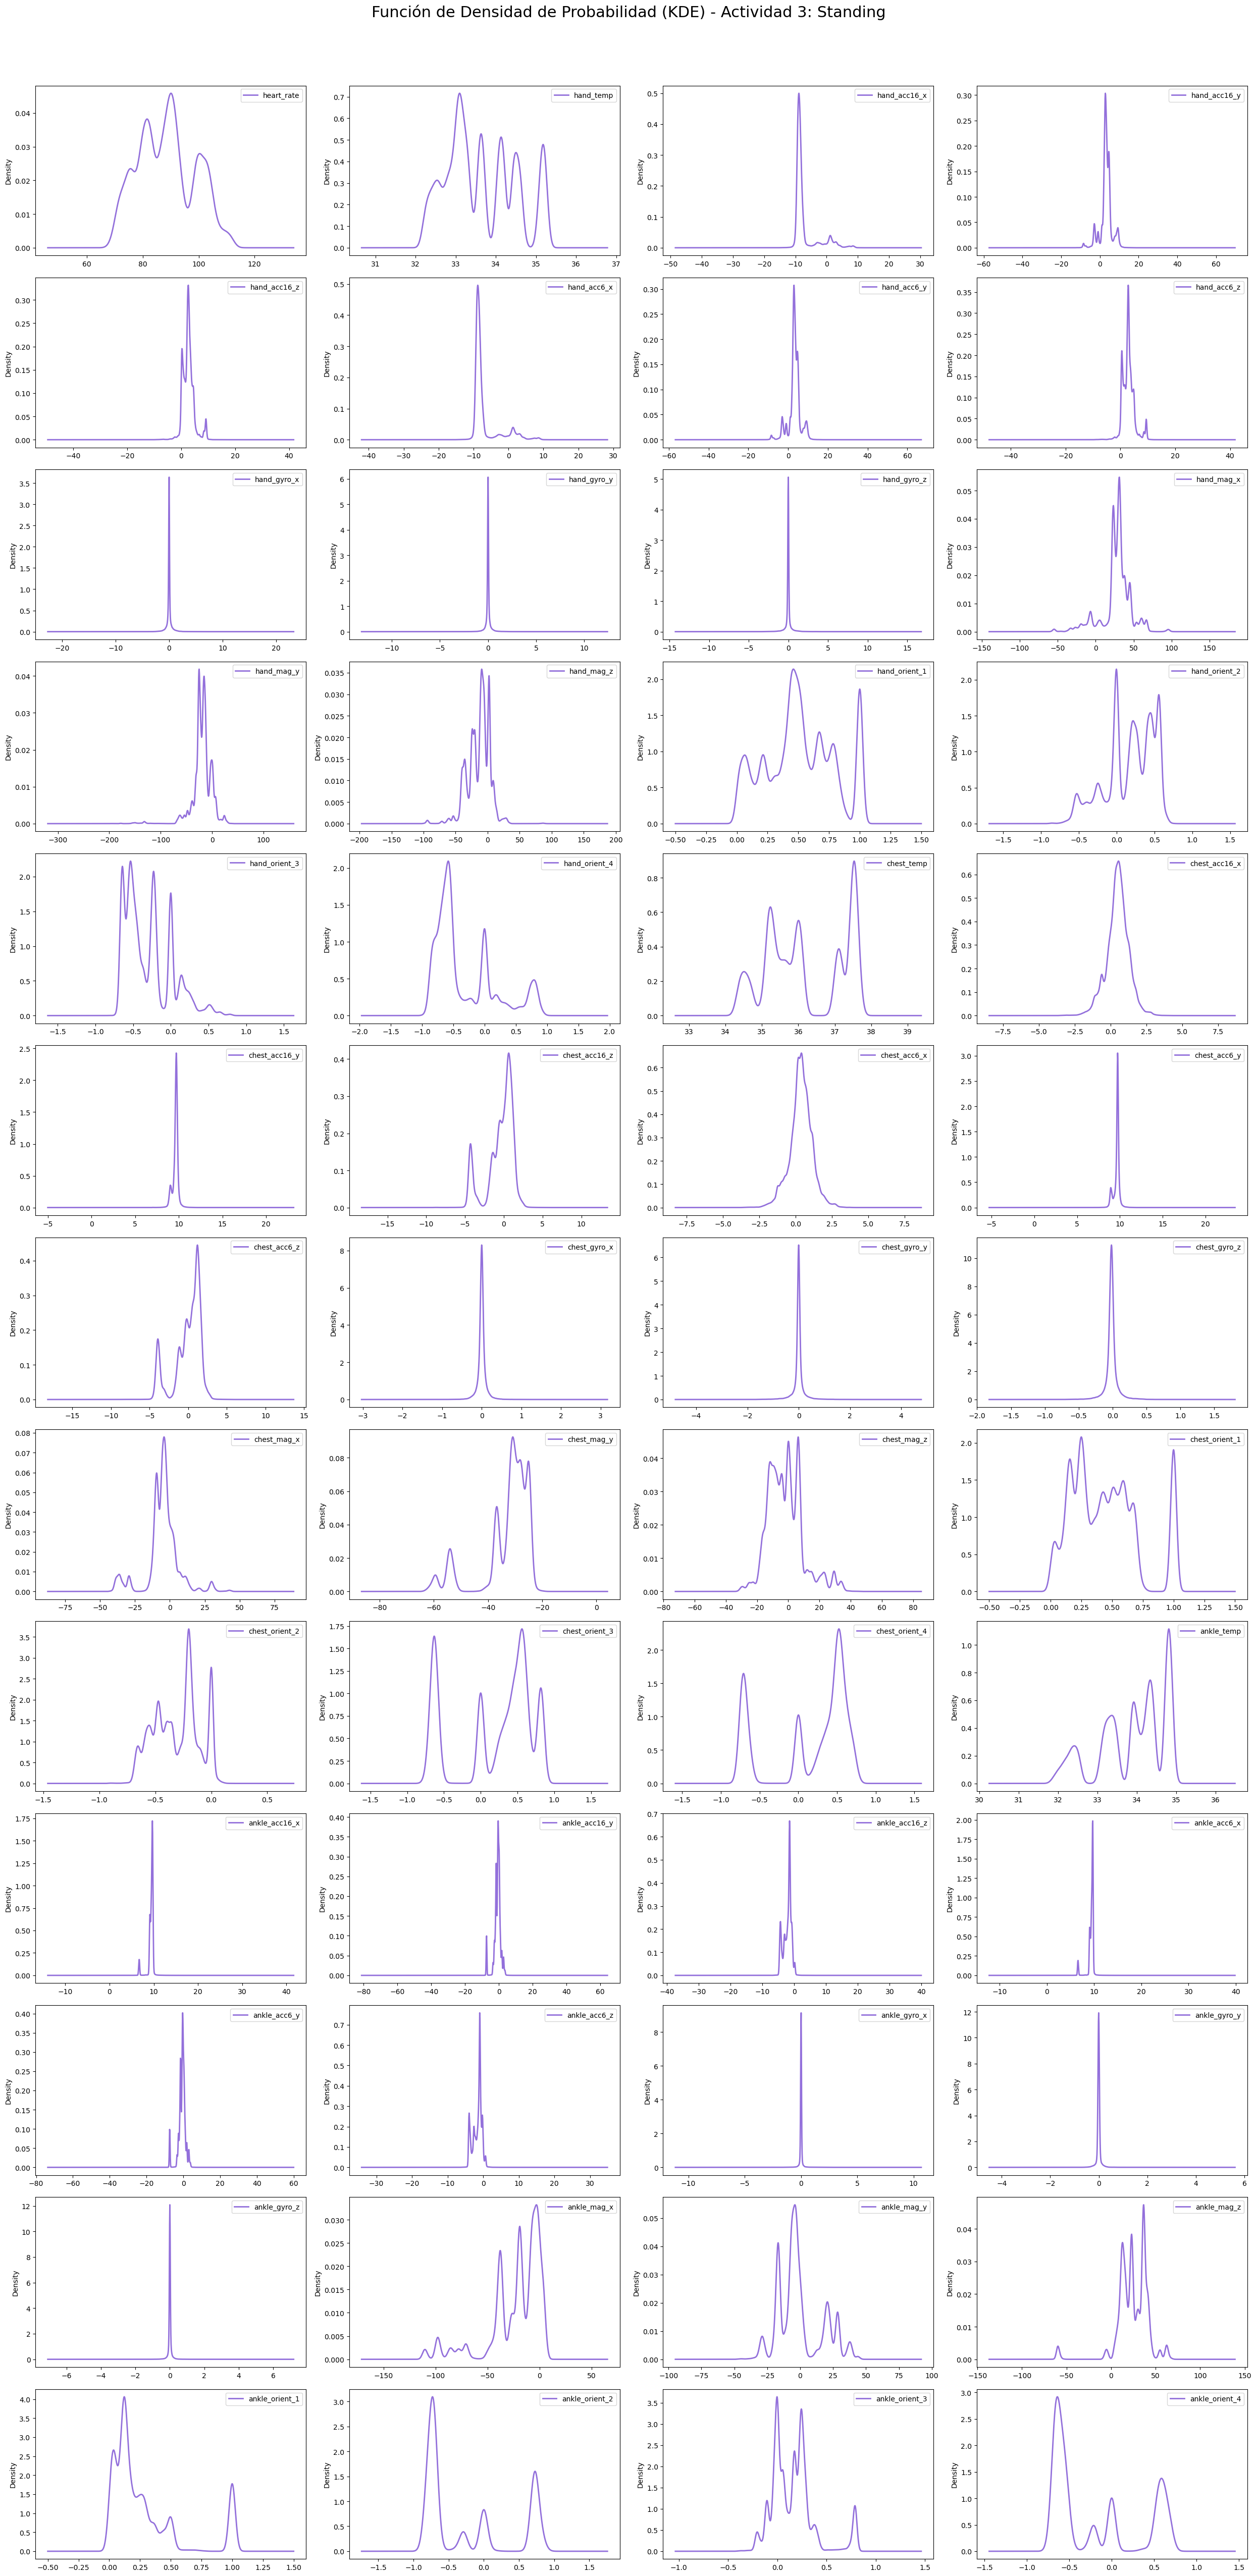

In [50]:
sensores_standing.plot(
    kind='density', 
    subplots=True, 
    layout=(13,4),  
    figsize=(25, 50),
    sharex=False,     
    color='mediumpurple', 
    linewidth=2
)

plt.suptitle('Función de Densidad de Probabilidad (KDE) - Actividad 3: Standing', fontsize=22, y=1.02)
plt.tight_layout()

plt.show

9. Genera la gráfica de cajas y bigotes para la distribución de los atributos de cada base de datos.

<function matplotlib.pyplot.show(close=None, block=None)>

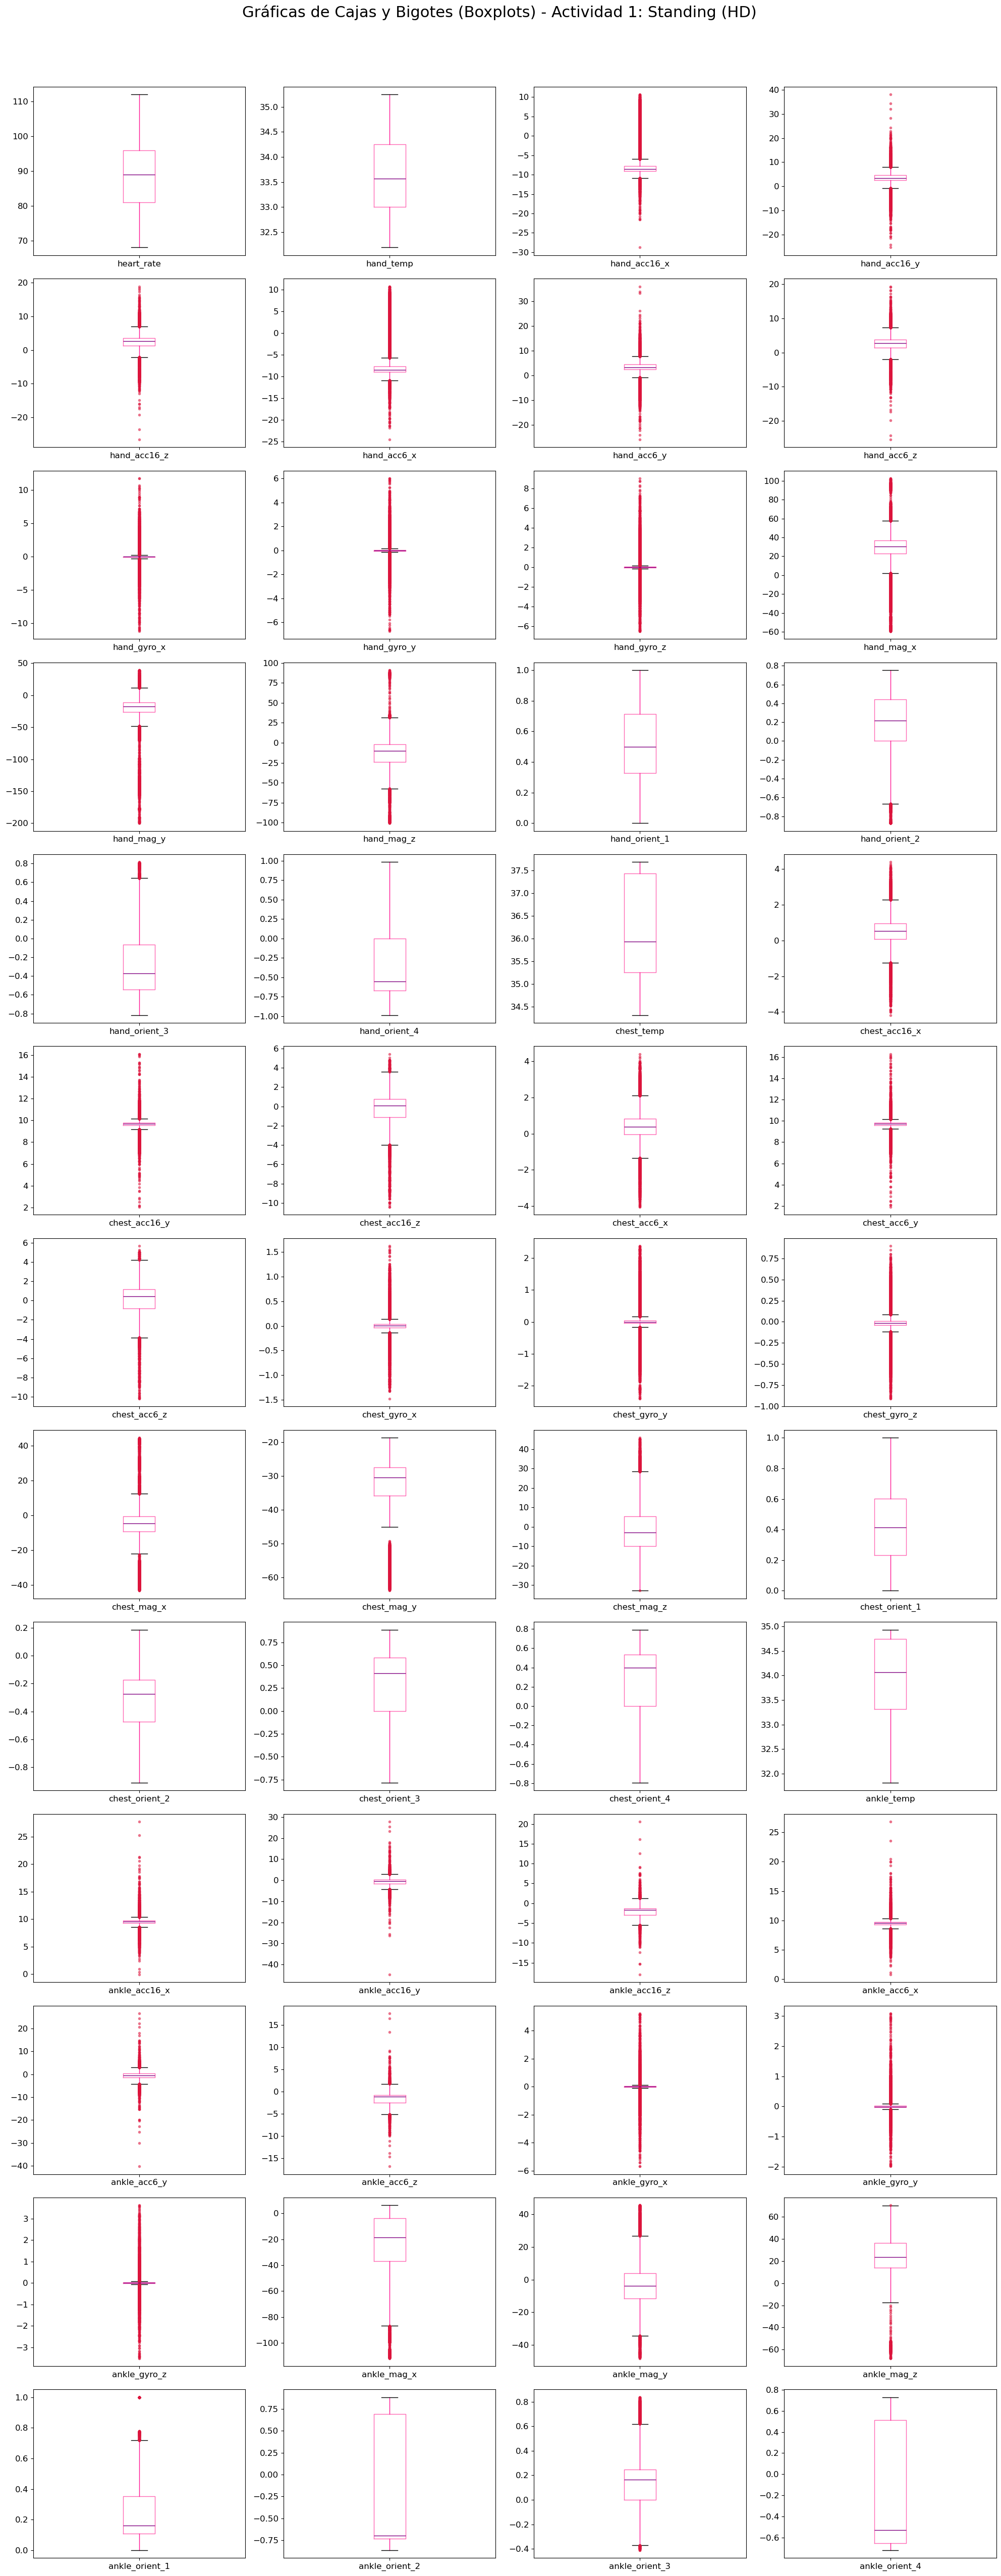

In [51]:
color_props = dict(boxes='hotpink', whiskers='deeppink', medians='purple', caps='black')
puntitos_props = dict(marker='o', markerfacecolor='crimson', markersize=4, alpha=0.6, markeredgecolor='none')

# Dibujamos el mosaico
sensores_standing.plot(
    kind='box', 
    subplots=True, 
    layout=(13,4),  
    figsize=(20, 50), 
    color=color_props,
    flierprops=puntitos_props,
    fontsize=12      
)


plt.suptitle('Gráficas de Cajas y Bigotes (Boxplots) - Actividad 1: Standing (HD)', fontsize=22, y=1.02)
plt.tight_layout()

plt.show

10. Genera la matriz de correlación de los atributos para cada una de las bases de datos.

<function matplotlib.pyplot.show(close=None, block=None)>

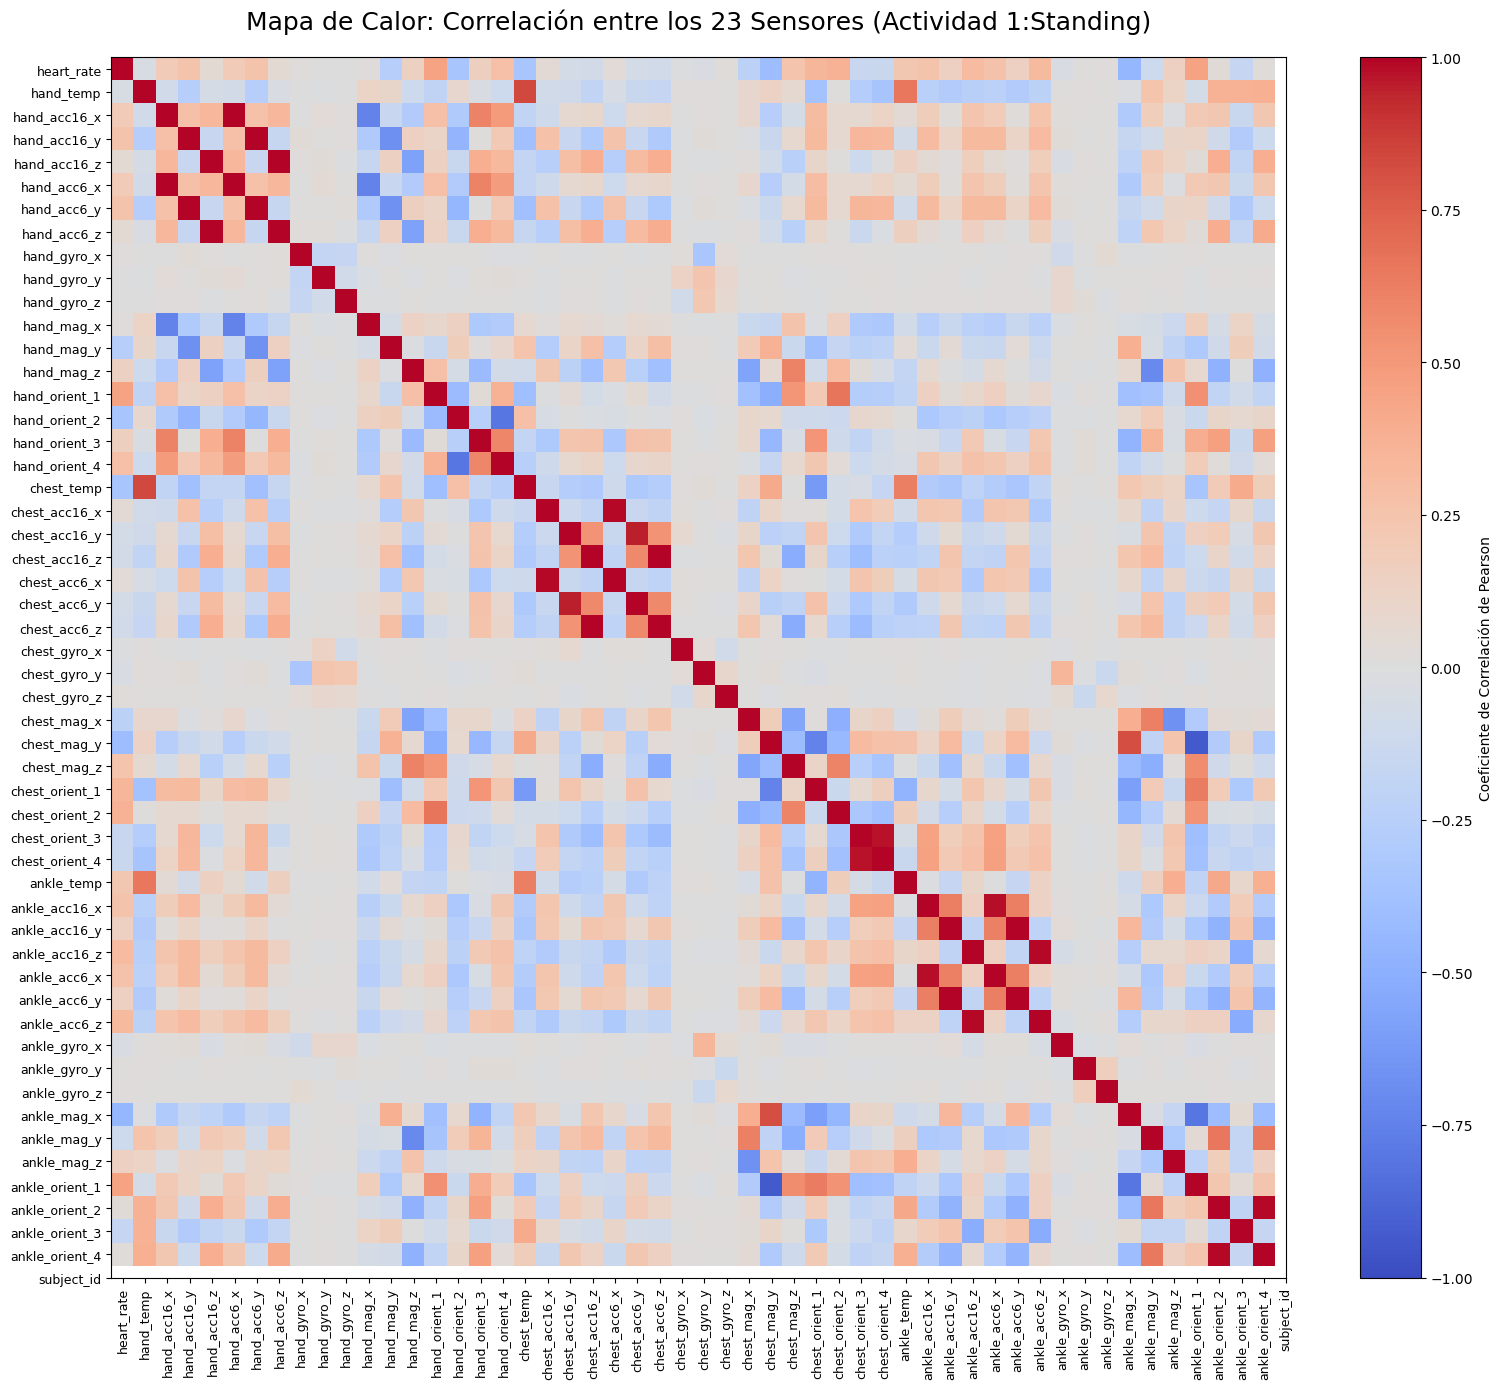

In [52]:
# Calculamos la matriz de correlación de Pearson
matriz_correlacion = sensores_standing.corr()

# Dibujamos el Mapa de Calor
plt.figure(figsize=(16, 14))

# Usamos imshow para dibujar la cuadrícula, coolwarm da rojo a los +1 y azul a los -1
imagen = plt.imshow(matriz_correlacion, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')

# Agregamos la barra de colores al lado
plt.colorbar(imagen, label='Coeficiente de Correlación de Pearson')
plt.title('Mapa de Calor: Correlación entre los 23 Sensores (Actividad 1:Standing)', fontsize=18, pad=20)

# Ponemos los nombres de las 45 columnas en los bordes
posiciones = np.arange(len(sensores_fisicos.columns))
plt.xticks(posiciones, sensores_fisicos.columns, rotation=90, fontsize=9)
plt.yticks(posiciones, sensores_fisicos.columns, fontsize=9)

plt.grid(False) 
plt.tight_layout()

plt.show

11. Genera la matriz de dispersión de los atributos para cada base de datos.

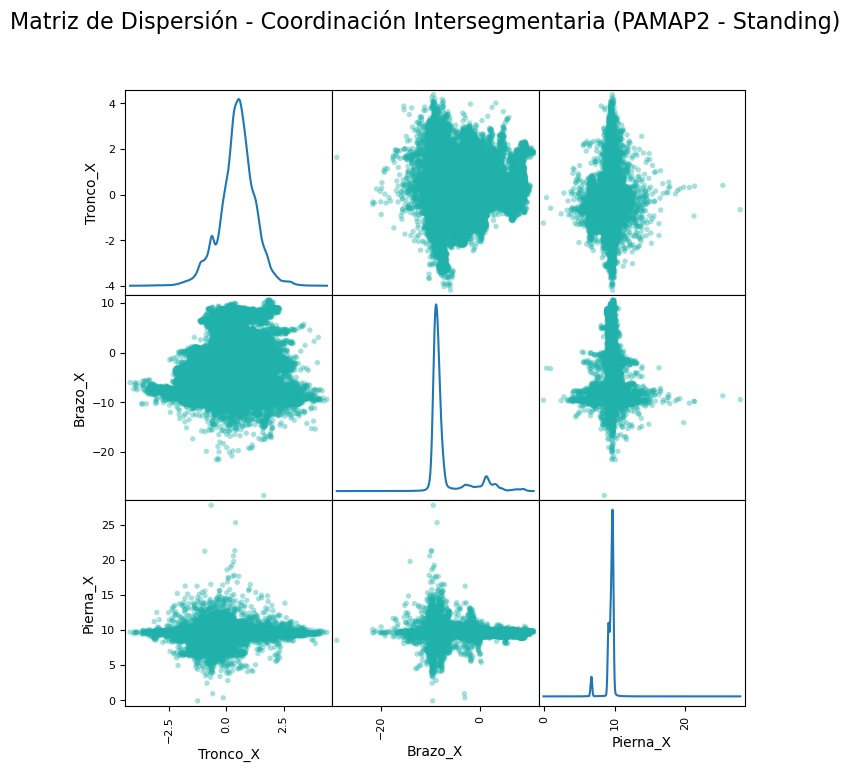

In [53]:
# Selección estratégica: un eje X por segmento corporal
sensores_estrategicos = [
    "chest_acc16_x",   # Tronco
    "hand_acc16_x",    # Brazo / Mano
    "ankle_acc16_x"    # Pierna
]

datos_scatter = sensores_standing[sensores_estrategicos].copy()

# Renombramos para visualización más clara
datos_scatter.columns = [
    "Tronco_X",
    "Brazo_X",
    "Pierna_X"
]

pd.plotting.scatter_matrix(
    datos_scatter,
    alpha=0.4,
    figsize=(8, 8),
    diagonal='kde',
    color='lightseagreen',
    marker='o',
    s=15
)

plt.suptitle(
    'Matriz de Dispersión - Coordinación Intersegmentaria (PAMAP2 - Standing)',
    fontsize=16
)

plt.show()

In [54]:
from sklearn.preprocessing import StandardScaler

# Separar variables
X = PAMAP2DATASET.drop(columns=["activity_id", "subject_id", "timestamp"])
y = PAMAP2DATASET["activity_id"]
subject_ids = PAMAP2DATASET["subject_id"]
timestamps = PAMAP2DATASET["timestamp"]

# Crear scaler
scaler = StandardScaler()

# Ajustar y transformar
X_scaled = scaler.fit_transform(X)

# Volver a DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Reconstruir dataset final
PAMAP2DATASET_scaled = pd.concat(
    [
        timestamps.reset_index(drop=True),
        X_scaled,
        y.reset_index(drop=True),
        subject_ids.reset_index(drop=True)
    ],
    axis=1
)

PAMAP2DATASET_scaled.head()

,timestamp,heart_rate,hand_temp,hand_acc16_x,hand_acc16_y,hand_acc16_z,hand_acc6_x,hand_acc6_y,hand_acc6_z,hand_gyro_x,hand_gyro_y,hand_gyro_z,hand_mag_x,hand_mag_y,hand_mag_z,hand_orient_1,hand_orient_2,hand_orient_3,hand_orient_4,chest_temp,chest_acc16_x,chest_acc16_y,chest_acc16_z,chest_acc6_x,chest_acc6_y,chest_acc6_z,chest_gyro_x,chest_gyro_y,chest_gyro_z,chest_mag_x,chest_mag_y,chest_mag_z,chest_orient_1,chest_orient_2,chest_orient_3,chest_orient_4,ankle_temp,ankle_acc16_x,ankle_acc16_y,ankle_acc16_z,ankle_acc6_x,ankle_acc6_y,ankle_acc6_z,ankle_gyro_x,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,ankle_orient_1,ankle_orient_2,ankle_orient_3,ankle_orient_4,activity_id,subject_id
0,8.38,-0.227001,-1.438278,1.225227,0.798521,0.088988,1.222976,0.854953,0.001346,-0.068223,0.027819,-0.006663,-0.270091,-2.275371,0.778801,1.419236,0.149116,0.413487,0.058746,-2.735451,-0.085340,0.304096,-0.040928,0.012622,0.311284,-0.054887,-0.026375,-0.028115,0.052657,-0.188901,-1.190648,1.896072,1.61553,1.381849,-0.115789,-0.126183,-2.847635,0.019913,-0.224063,0.663961,0.023482,-0.240534,0.736485,-0.000312,0.073335,-0.013749,-1.507939,-1.876437,-3.694706,1.981698,-0.037862,-0.954803,0.039708,0,101
1,8.39,NaN,-1.438278,1.194507,0.792923,0.128352,1.215534,0.820137,0.076183,-0.015962,0.017613,0.008705,-0.260995,-2.275769,0.767447,1.419236,0.149116,0.413487,0.058746,-2.735451,-0.035078,0.259889,0.005953,-0.006128,0.304129,-0.058474,0.020263,-0.012775,-0.069961,-0.155777,-1.150118,1.890375,1.61553,1.381849,-0.115789,-0.126183,-2.847635,0.025956,-0.212852,0.631380,0.017835,-0.250020,0.727110,-0.014170,0.050056,-0.004007,-1.436911,-1.873291,-3.713492,1.981698,-0.037862,-0.954803,0.039708,0,101
2,8.40,NaN,-1.438278,1.225451,0.798573,0.099004,1.200549,0.817764,0.099806,-0.041831,0.000495,-0.000565,-0.288350,-2.288108,0.801339,1.419236,0.149116,0.413487,0.058746,-2.735451,-0.086874,0.286192,-0.059435,-0.043849,0.289840,-0.080077,-0.113081,0.047659,0.064796,-0.194300,-1.239267,1.920562,1.61553,1.381849,-0.115789,-0.126183,-2.847635,0.007702,-0.235331,0.718139,0.020646,-0.245280,0.727055,-0.005236,0.058078,0.008001,-1.483959,-1.897440,-3.707317,1.981698,-0.037862,-0.954803,0.039708,0,101
3,8.41,NaN,-1.438278,1.175519,0.787018,0.127941,1.205578,0.817728,0.099799,0.001043,0.000760,0.001666,-0.261341,-2.289112,0.750443,1.419236,0.149116,0.413487,0.058746,-2.735451,0.007603,0.241684,-0.049346,-0.053655,0.271931,-0.094542,0.004911,-0.035013,0.001293,-0.198417,-1.114000,1.889883,1.61553,1.381849,-0.115789,-0.126183,-2.847635,0.007475,-0.240835,0.707352,0.020691,-0.252378,0.746072,-0.005086,0.023802,0.001912,-1.466638,-1.867350,-3.707105,1.981698,-0.037862,-0.954803,0.039708,0,101
4,8.42,NaN,-1.438278,1.201356,0.835234,0.138292,1.188102,0.827832,0.107657,0.012312,-0.015592,-0.032470,-0.233432,-2.259052,0.744835,1.419236,0.149116,0.413487,0.058746,-2.735451,-0.037380,0.233032,-0.021804,-0.007012,0.253905,-0.062227,-0.023285,-0.036346,-0.016797,-0.235685,-1.237785,1.913891,1.61553,1.381849,-0.115789,-0.126183,-2.847635,0.026658,-0.224144,0.674922,0.023500,-0.254747,0.746062,0.003784,0.033856,-0.005739,-1.525477,-1.896241,-3.700891,1.981698,-0.037862,-0.954803,0.039708,0,101
